In [11]:
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
def svd_approx(A, cutoff=0, plot=False, normalization=False):
    
    U, S, Vh = np.linalg.svd(A, full_matrices=False)
    # Up = U[:, :dim]
    # Sp = S[:dim]
    # Vhp = Vh[:dim, :]
    
    Lambda = S*S 
    
    dim = np.searchsorted(-Lambda, -cutoff, side='left')
    Up = U[:, :dim]
    Sp = S[:dim]
    Vhp = Vh[:dim, :]
    
    Approx = Up @ np.diag(Sp) @ Vhp
    chi = np.linalg.norm(A - Approx)
    
    if normalization:
        Sp = Sp / np.linalg.norm(Sp)
        chi = np.linalg.norm(A - Approx) / np.linalg.norm(A)
    
    if plot:
        fig, ax = plt.subplots()
        bins = np.logspace(-5, np.log(S.max()), 20)
        ax.hist(S, bins=bins, label="origin")
        ax.hist(Sp, bins=bins, fill=False, lw=1, edgecolor='r', label='truncated')
        ax.set_xscale('log')
        ax.legend()
        plt.title(f'chi = {chi:.2e}')
        plt.show()
    
    return Up, Sp, Vhp, chi

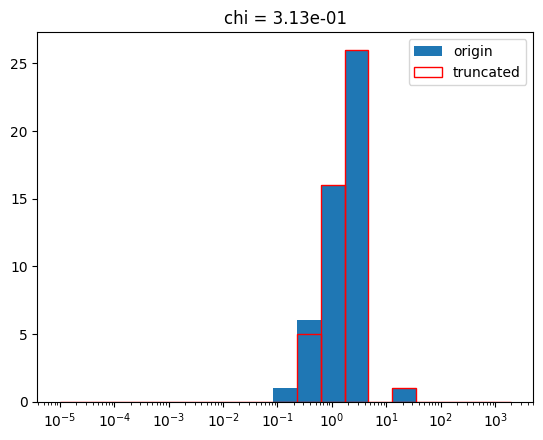

In [46]:
A = np.random.rand(50, 55)
u, s, v, chi = svd_approx(A, 48, plot=True)

In [1]:
import numpy as np 

a = np.array([[ 6, 5, 6], [6, 2, 1]])

U, S, Vh = np.linalg.svd(a, full_matrices=False)
U, S, Vh

(array([[-0.85851611, -0.51278659],
        [-0.51278659,  0.85851611]]),
 array([11.31632857,  3.1528888 ]),
 array([[-0.7270747 , -0.46995399, -0.50050537],
        [ 0.65792904, -0.26861104, -0.70354636]]))

In [2]:
U @ np.diag(S) @ Vh 

array([[6., 5., 6.],
       [6., 2., 1.]])

In [ ]:
U, S, Vh = np.linalg.svd(a)
U, S, Vh